# Building a ANN using pytorch

In [96]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [97]:
# set random seeds for reproducibility
torch.manual_seed(42)

In [98]:
df=pd.read_csv(r"../Dataset/fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


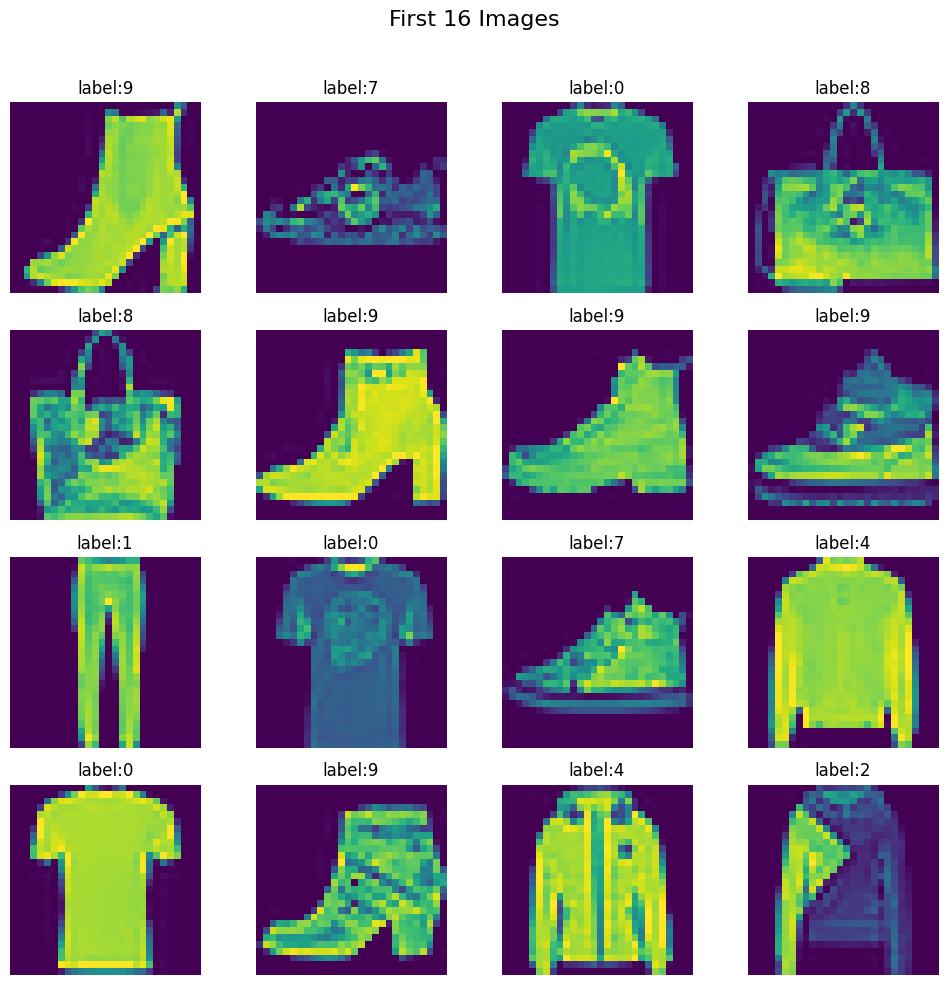

In [99]:
# create a 4X4 grid of images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)

# plot the first 16 images from Dataset

for i, ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"label:{df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [100]:
# train test split

X=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [101]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [102]:
# Scaling the features
X_train=X_train/255.0
X_test=X_test/255.0

In [103]:
# Create CustomDataset Class

class CustomDataset(Dataset):

    def __init__(self,features,labels):
        self.features=torch.tensor(features,dtype=torch.float32)
        self.labels=torch.tensor(labels,dtype=torch.long)

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self,index):
        return self.features[index],self.labels[index]


In [ ]:
# Create train dataset object
train_dataset=CustomDataset(X_train,y_train)
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [105]:
# Create test_dataset_object
test_dataset=CustomDataset(X_test,y_test)

In [106]:
# create train and test loader
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

```TEXT

Input Features
      │
      ▼
Linear(num_features → 128)
      │
      ▼
ReLU
      │
      ▼
Linear(128 → 64)
      │
      ▼
ReLU
      │
      ▼
Linear(64 → 10)
      │
      ▼
Output

the first hidden layer often has more neurons than the input, allowing the network to learn richer features. Later layers gradually compress this into outputs.

In [107]:
# Define NN class
import torch.nn as nn
class MyNN(nn.Module):

    def __init__(self, num_features):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.model(x)

In [108]:
# set learning rate and epochs

epochs=100
learning_rate=0.1

In [109]:
# instatiate the model

model=MyNN(X_train.shape[1])


# loss function

criterion=nn.CrossEntropyLoss()


# optimizer
optimizer=optim.SGD(model.parameters(),lr=learning_rate)

In [110]:
# training loop

for epoch in range(epochs):
    total_epoch_loss=0
    for batch_features,batch_labels in train_loader:
        #forward pass

        outputs=model(batch_features)

        # calculate loss
        loss=criterion(outputs,batch_labels)

        # back pass
        optimizer.zero_grad()
        loss.backward()


        # update gradient
        optimizer.step()

        total_epoch_loss=total_epoch_loss+loss.item()

    average_loss=total_epoch_loss/len(train_loader)
    print(f"Epoch {epoch+1},loss:{average_loss}")

Epoch 1,loss:1.3216368544101715
Epoch 2,loss:0.779336547255516
Epoch 3,loss:0.6427524554729461
Epoch 4,loss:0.5751657483975092
Epoch 5,loss:0.5278772680958113
Epoch 6,loss:0.49531099090973535
Epoch 7,loss:0.4619268513719241
Epoch 8,loss:0.4355265058577061
Epoch 9,loss:0.41890644033749896
Epoch 10,loss:0.39741519302129746
Epoch 11,loss:0.38665722946325937
Epoch 12,loss:0.3712778009970983
Epoch 13,loss:0.34902072181304294
Epoch 14,loss:0.3476298263172309
Epoch 15,loss:0.31585514520605407
Epoch 16,loss:0.3119578541815281
Epoch 17,loss:0.29582366382082304
Epoch 18,loss:0.2882651210824649
Epoch 19,loss:0.2712535863866409
Epoch 20,loss:0.2599384429057439
Epoch 21,loss:0.25771103824178376
Epoch 22,loss:0.2467067078500986
Epoch 23,loss:0.23920486075182756
Epoch 24,loss:0.22289435726900894
Epoch 25,loss:0.22345758318901063
Epoch 26,loss:0.21021605119109155
Epoch 27,loss:0.2206080826371908
Epoch 28,loss:0.21161145582795143
Epoch 29,loss:0.1861052716895938
Epoch 30,loss:0.1848285266260306
Epoch 3

In [111]:
# set model to eval mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [112]:
# evalutaion code

total=0
correct=0

with torch.no_grad():
    for batch_features,batch_labels in test_loader:
        outputs=model(batch_features)

        _,predicted=torch.max(outputs,1)
        total=total+batch_labels.shape[0]

        correct=correct+(predicted==batch_labels).sum().item()


print(correct/total)

0.8316666666666667


The accuracy of model is 0.83 after training our model.

## To improve accuracy of model

- We have used only 6000 images out of 70,000. 
- We can try different optimizer like Adam, RMs etc
- we can try different learning rate and epochs
- use regularization and dropouts